In [1]:
import pandas as pd

In [2]:
import numpy as np

# Loading all three files

In [ ]:
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'], 
                    dtype={'StateHoliday': str}, low_memory=False)
store = pd.read_csv('../data/raw/store.csv')

# Quick sanity check

In [ ]:
print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("\nTrain columns:", train.columns.tolist())
print("Store columns:", store.columns.tolist())

Train shape: (1017209, 9)
Store shape: (1115, 10)

Train columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
Store columns: ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [7]:
for name, df in [("train", train), ("store", store)]:
    print(f"\n===== {name} =====")
    print(df.head())
    print(df.info())
    print(df.describe())
    print("\nMissing values:")
    print(df.isnull().sum())


===== train =====
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1            0   
1      2          5 2015-07-31   6064        625     1      1            0   
2      3          5 2015-07-31   8314        821     1      1            0   
3      4          5 2015-07-31  13995       1498     1      1            0   
4      5          5 2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-

# 1. Missing value counts and percentages

In [ ]:
missing = train.isnull().sum()
missing_pct = (missing / len(train)) * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0])

Empty DataFrame
Columns: [count, pct]
Index: []


# 2. Duplicate rows

In [ ]:
print("\nDuplicate rows:", train.duplicated().sum())


Duplicate rows: 0


# 3. Check if any Sales are 0 or negative (anomalies)

In [ ]:
print("\nSales = 0:", (train['Sales'] == 0).sum())
print("Open but Sales=0:", ((train['Open']==1) & (train['Sales']==0)).sum())


Sales = 0: 172871
Open but Sales=0: 54


# 4. Check store.csv missing values

In [ ]:
print("\nStore missing values:")
print(store.isnull().sum())


Store missing values:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sales distribution

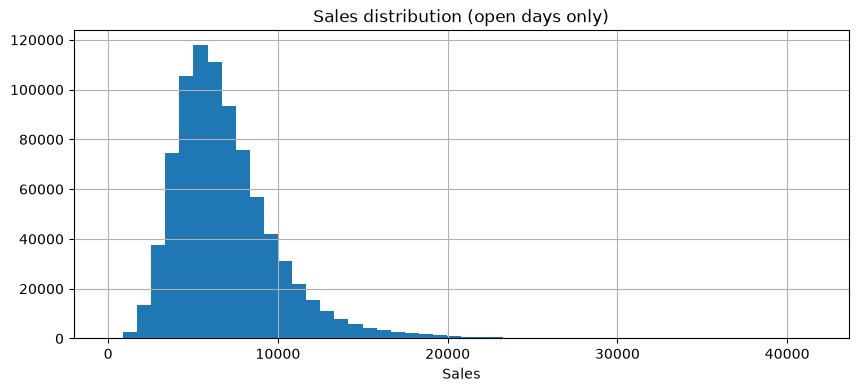

In [ ]:
plt.figure(figsize=(10, 4))
train[train['Sales'] > 0]['Sales'].hist(bins=50)
plt.title('Sales distribution (open days only)')
plt.xlabel('Sales')
plt.savefig('../reports/sales_distribution.png')
plt.show()

# 2. Sales over time

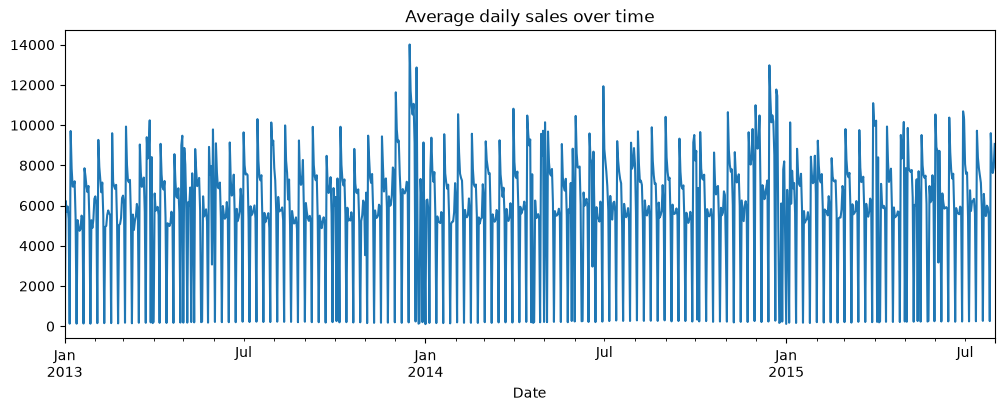

In [ ]:
daily = train.groupby('Date')['Sales'].mean()
plt.figure(figsize=(12, 4))
daily.plot()
plt.title('Average daily sales over time')
plt.savefig('../reports/sales_over_time.png')
plt.show()

# 3. Missing value heatmap

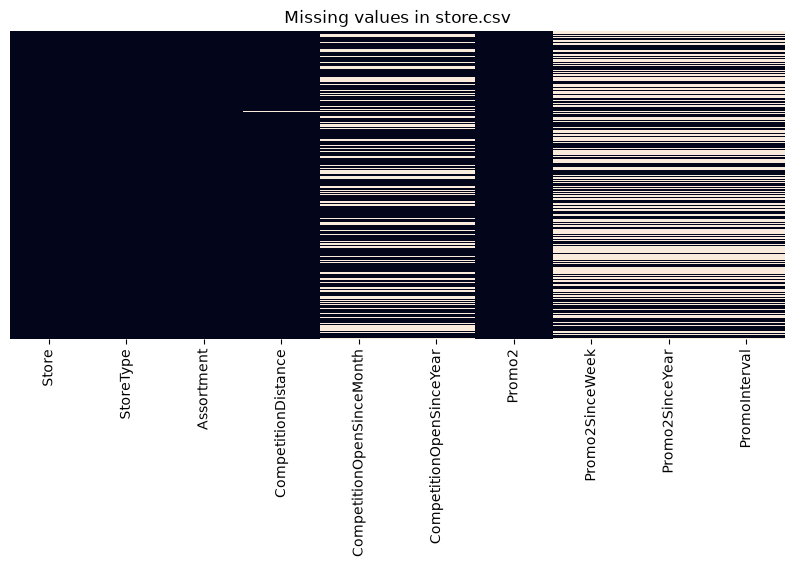

In [ ]:
plt.figure(figsize=(10, 4))
sns.heatmap(store.isnull(), cbar=False, yticklabels=False)
plt.title('Missing values in store.csv')
plt.savefig('../reports/missing_values.png')
plt.show()

# StateHoliday unique values (confirm the dtype fix worked)

In [ ]:
print("StateHoliday values:", train['StateHoliday'].unique())

StateHoliday values: <StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str


# Date range of the dataset

In [ ]:
print("Date range:", train['Date'].min(), "to", train['Date'].max())

Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


# Unique stores in train

In [ ]:
print("Unique stores:", train['Store'].nunique())

Unique stores: 1115
